In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

# 文件路径格式：/content/drive/MyDrive/你的文件夹/文件名
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/malaysia_house_price_data_2025.csv')
df.head()

,Township,Area,State,Tenure,Type,Median_Price,Median_PSF,Transactions
0,SCIENTEX SUNGAI DUA,Tasek Gelugor,Penang,Freehold,Terrace House,331800.0,304.0,593
1,BANDAR PUTRA,Kulai,Johor,Freehold,"Cluster House, Terrace House",590900.0,322.0,519
2,TAMAN LAGENDA TROPIKA TAPAH,Chenderiang,Perak,Freehold,Terrace House,229954.0,130.0,414
3,SCIENTEX JASIN MUTIARA,Bemban,Melaka,Freehold,Terrace House,255600.0,218.0,391
4,TAMAN LAGENDA AMAN,Tapah,Perak,Leasehold,Terrace House,219300.0,168.0,363


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(df.shape)
df.info()

(2000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Township      2000 non-null   object 
 1   Area          2000 non-null   object 
 2   State         2000 non-null   object 
 3   Tenure        2000 non-null   object 
 4   Type          2000 non-null   object 
 5   Median_Price  2000 non-null   float64
 6   Median_PSF    2000 non-null   float64
 7   Transactions  2000 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 125.1+ KB


In [8]:
df.describe()

,Median_Price,Median_PSF,Transactions
count,2.000000e+03,2000.000000,2000.000000
mean,4.906854e+05,328.862500,28.091500
std,4.686322e+05,193.281739,37.702385
min,2.704900e+04,38.000000,10.000000
25%,2.699500e+05,201.000000,12.000000
50%,3.900000e+05,293.000000,16.000000
75%,5.735000e+05,412.000000,28.000000
max,1.142050e+07,3017.000000,593.000000


In [9]:
df['State'].value_counts()

,count
State,
Selangor,545
Johor,377
Perak,194
Penang,187
Kuala Lumpur,176
Negeri Sembilan,135
Kedah,103
Melaka,98
Pahang,71


In [10]:
df['Type'].value_counts()

,count
Type,
Terrace House,956
Apartment,197
Condominium,167
Flat,131
"Terrace House, Semi D",99
Service Residence,96
"Semi D, Terrace House",83
Semi D,43
"Terrace House, Cluster House",32


In [11]:
df['Tenure'].value_counts()

,count
Tenure,
Freehold,1318
Leasehold,624
"Freehold, Leasehold",31
"Leasehold, Freehold",27


In [12]:
df['Type_Clean'] = df['Type'].str.split(',').str[0].str.strip()
df['Type_Clean'].value_counts()

,count
Type_Clean,
Terrace House,1127
Apartment,198
Condominium,168
Semi D,147
Flat,134
Service Residence,96
Cluster House,58
Bungalow,53
Town House,19


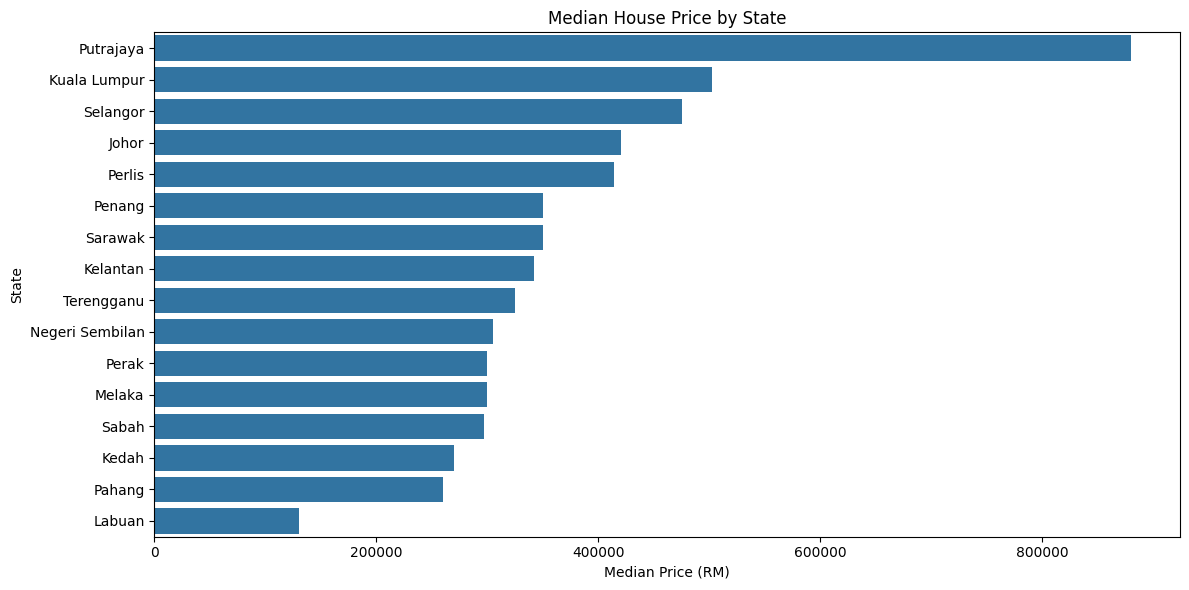

In [13]:
state_price = df.groupby('State')['Median_Price'].median().reset_index()
state_price = state_price.sort_values('Median_Price', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=state_price, x='Median_Price', y='State')
plt.title('Median House Price by State')
plt.xlabel('Median Price (RM)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

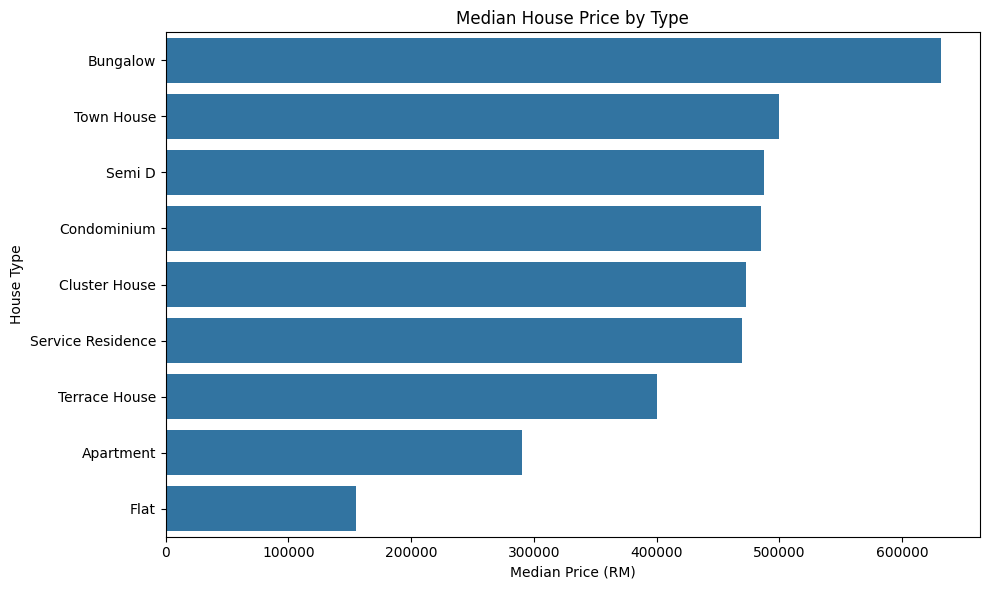

In [14]:
type_price = df.groupby('Type_Clean')['Median_Price'].median().reset_index()
type_price = type_price.sort_values('Median_Price', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=type_price, x='Median_Price', y='Type_Clean')
plt.title('Median House Price by Type')
plt.xlabel('Median Price (RM)')
plt.ylabel('House Type')
plt.tight_layout()
plt.show()

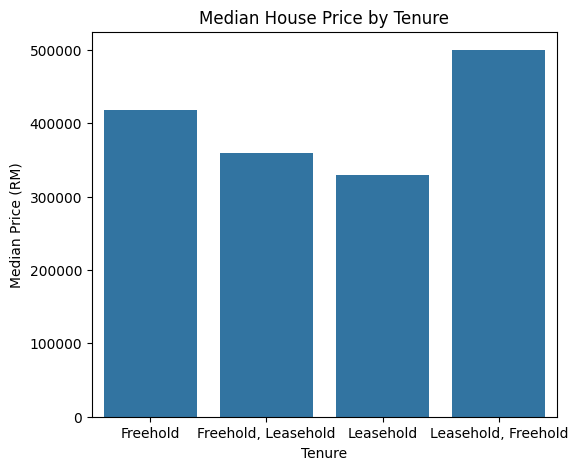

In [15]:
tenure_price = df.groupby('Tenure')['Median_Price'].median().reset_index()

plt.figure(figsize=(6, 5))
sns.barplot(data=tenure_price, x='Tenure', y='Median_Price')
plt.title('Median House Price by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Median Price (RM)')
plt.show()

In [16]:
df['Tenure'].value_counts()

,count
Tenure,
Freehold,1318
Leasehold,624
"Freehold, Leasehold",31
"Leasehold, Freehold",27


In [17]:
df['Tenure_Clean'] = df['Tenure'].str.split(',').str[0].str.strip()
df['Tenure_Clean'].value_counts()

,count
Tenure_Clean,
Freehold,1349
Leasehold,651


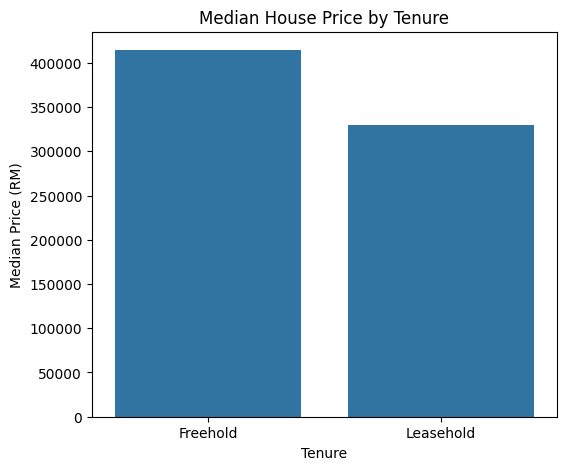

In [18]:
tenure_price = df.groupby('Tenure_Clean')['Median_Price'].median().reset_index()

plt.figure(figsize=(6, 5))
sns.barplot(data=tenure_price, x='Tenure_Clean', y='Median_Price')
plt.title('Median House Price by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Median Price (RM)')
plt.show()

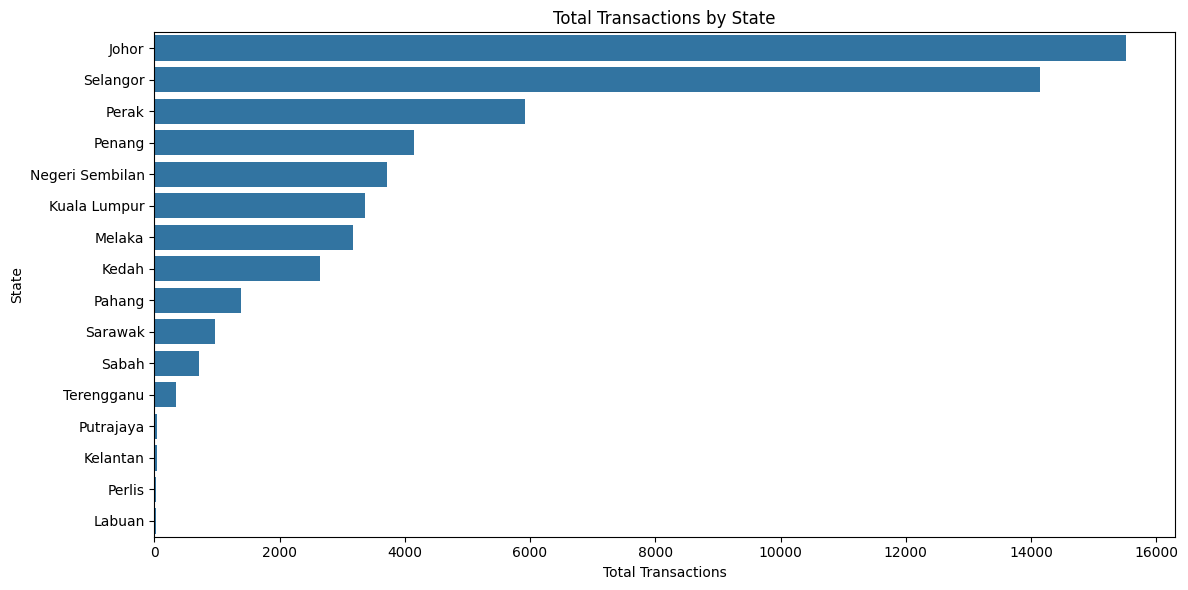

In [19]:
state_transactions = df.groupby('State')['Transactions'].sum().reset_index()
state_transactions = state_transactions.sort_values('Transactions', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=state_transactions, x='Transactions', y='State')
plt.title('Total Transactions by State')
plt.xlabel('Total Transactions')
plt.ylabel('State')
plt.tight_layout()
plt.show()

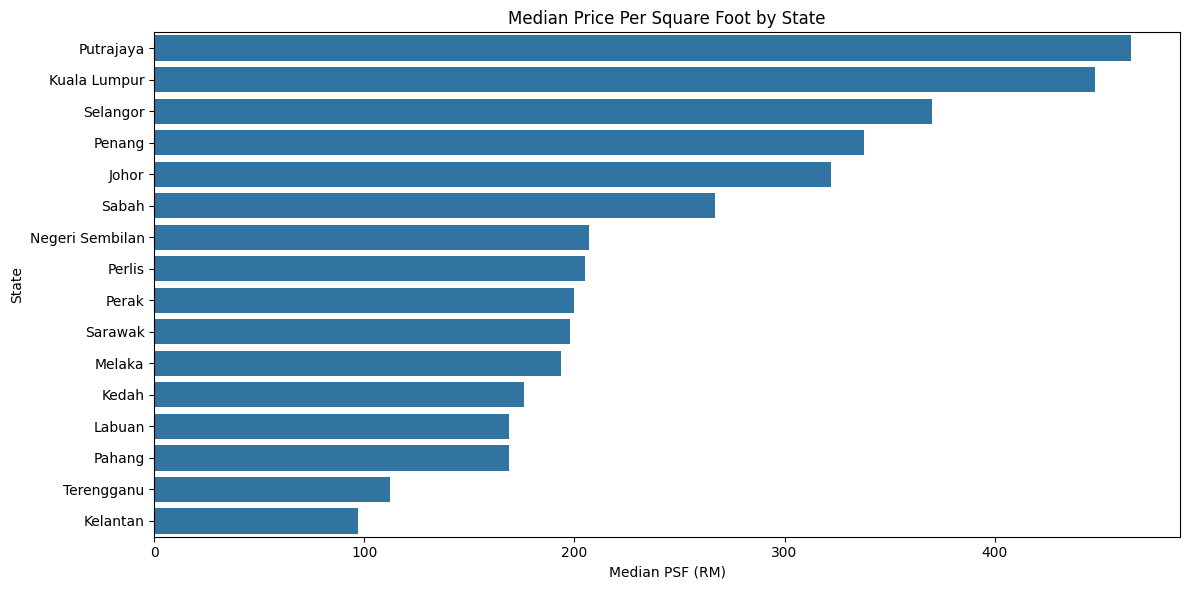

In [20]:
state_psf = df.groupby('State')['Median_PSF'].median().reset_index()
state_psf = state_psf.sort_values('Median_PSF', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=state_psf, x='Median_PSF', y='State')
plt.title('Median Price Per Square Foot by State')
plt.xlabel('Median PSF (RM)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

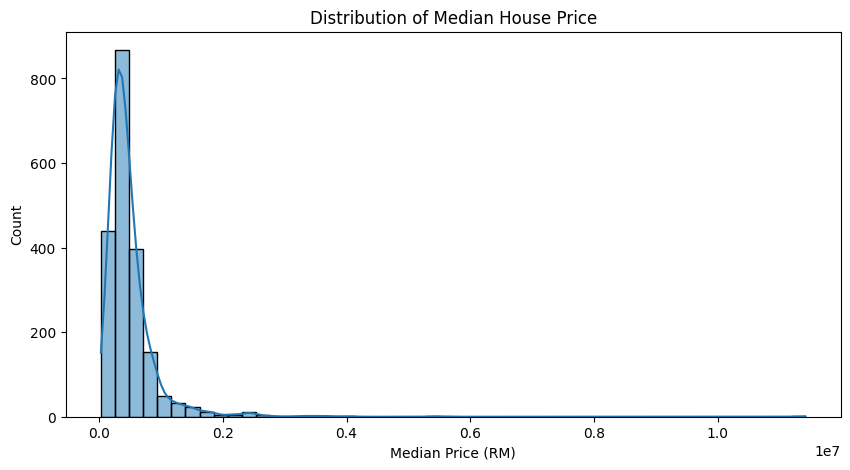

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Median_Price'], bins=50, kde=True)
plt.title('Distribution of Median House Price')
plt.xlabel('Median Price (RM)')
plt.ylabel('Count')
plt.show()

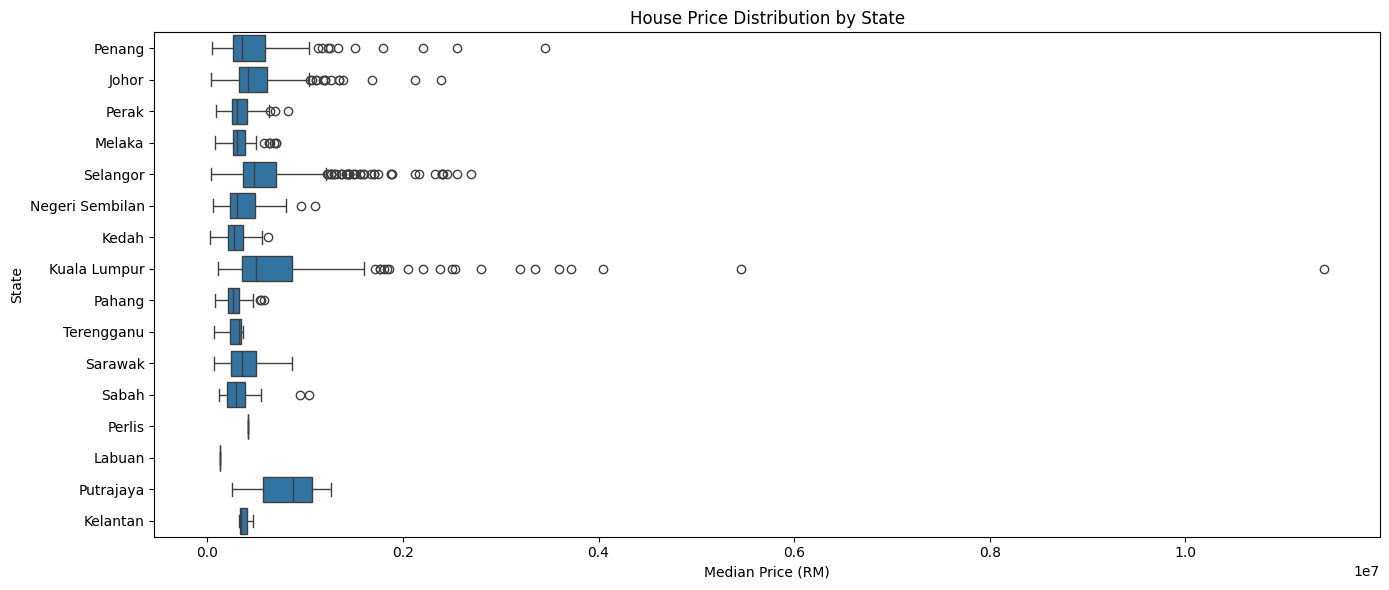

In [22]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Median_Price', y='State')
plt.title('House Price Distribution by State')
plt.xlabel('Median Price (RM)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [23]:
print("""
=== Malaysia House Price Analysis - Key Findings ===

1. Most Expensive State:
   - Putrajaya has the highest median house price.
   - Kuala Lumpur has extreme outliers reaching up to RM 11 million.

2. House Type:
   - Bungalow is the most expensive house type.
   - Terrace House is the most common type with 1,127 listings.

3. Tenure:
   - Freehold properties are priced higher than Leasehold.

4. Transaction Volume:
   - Johor has the highest number of transactions,
     likely driven by demand from Singapore buyers.

5. Price Distribution:
   - Penang, Johor, Selangor, and KL show many high-price outliers,
     indicating active luxury property markets.
""")


=== Malaysia House Price Analysis - Key Findings ===

1. Most Expensive State:
   - Putrajaya has the highest median house price.
   - Kuala Lumpur has extreme outliers reaching up to RM 11 million.

2. House Type:
   - Bungalow is the most expensive house type.
   - Terrace House is the most common type with 1,127 listings.

3. Tenure:
   - Freehold properties are priced higher than Leasehold.

4. Transaction Volume:
   - Johor has the highest number of transactions,
     likely driven by demand from Singapore buyers.

5. Price Distribution:
   - Penang, Johor, Selangor, and KL show many high-price outliers,
     indicating active luxury property markets.



In [24]:
top10_township = df.nlargest(10, 'Median_Price')[['Township', 'State', 'Type_Clean', 'Median_Price']]
print(top10_township)

                                 Township         State         Type_Clean  \
1312                   Four Seasons Place  Kuala Lumpur  Service Residence   
1858                  Pavilion Residences  Kuala Lumpur  Service Residence   
1818                             The Oval  Kuala Lumpur  Service Residence   
744                              St Regis  Kuala Lumpur  Service Residence   
216   DAMANSARA HEIGHTS (BUKIT DAMANSARA)  Kuala Lumpur           Bungalow   
621                        TANJONG PINANG        Penang      Terrace House   
902                  10 Mont Kiara @ MK10  Kuala Lumpur        Condominium   
1806                             18 Madge  Kuala Lumpur        Condominium   
630                  11 Mont Kiara @ MK11  Kuala Lumpur        Condominium   
954                             TWIN PALM      Selangor           Bungalow   

      Median_Price  
1312    11420500.0  
1858     5460000.0  
1818     4045824.0  
744      3715000.0  
216      3600000.0  
621      345000

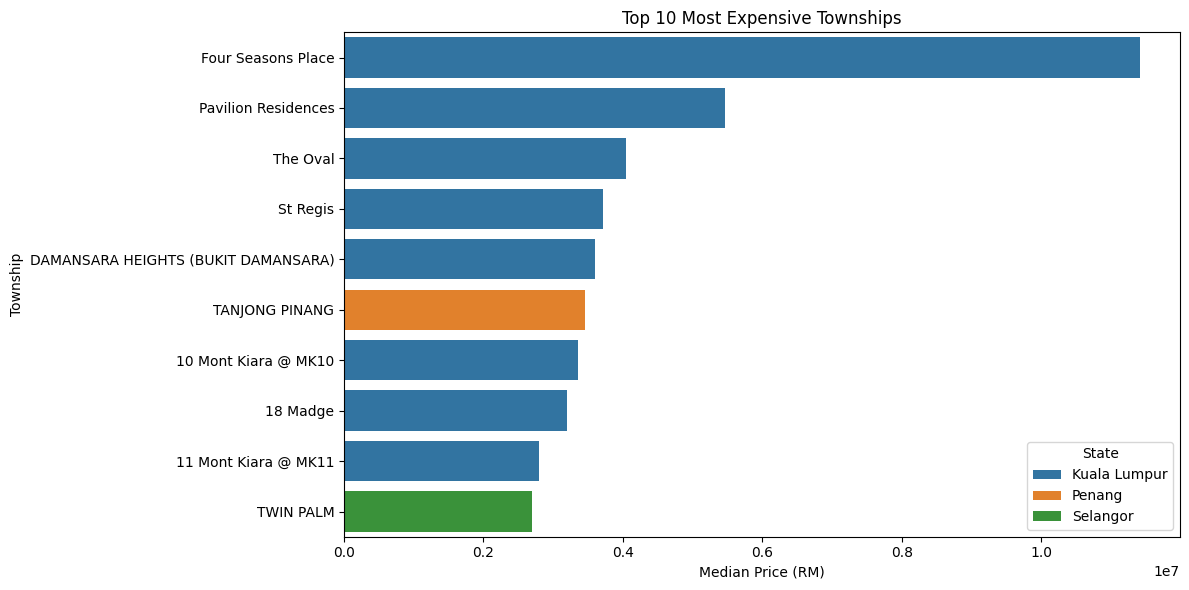

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top10_township, x='Median_Price', y='Township', hue='State')
plt.title('Top 10 Most Expensive Townships')
plt.xlabel('Median Price (RM)')
plt.ylabel('Township')
plt.tight_layout()
plt.show()

In [26]:
kl = df[df['State'] == 'Kuala Lumpur'].sort_values('Median_Price', ascending=False)
print(kl[['Township', 'Type_Clean', 'Median_Price']].head(10))

                                 Township         Type_Clean  Median_Price
1312                   Four Seasons Place  Service Residence    11420500.0
1858                  Pavilion Residences  Service Residence     5460000.0
1818                             The Oval  Service Residence     4045824.0
744                              St Regis  Service Residence     3715000.0
216   DAMANSARA HEIGHTS (BUKIT DAMANSARA)           Bungalow     3600000.0
902                  10 Mont Kiara @ MK10        Condominium     3350000.0
1806                             18 Madge        Condominium     3200728.0
630                  11 Mont Kiara @ MK11        Condominium     2800000.0
1329                     Pavilion Hilltop        Condominium     2531000.0
820                       BUKIT BANDARAYA           Bungalow     2500000.0


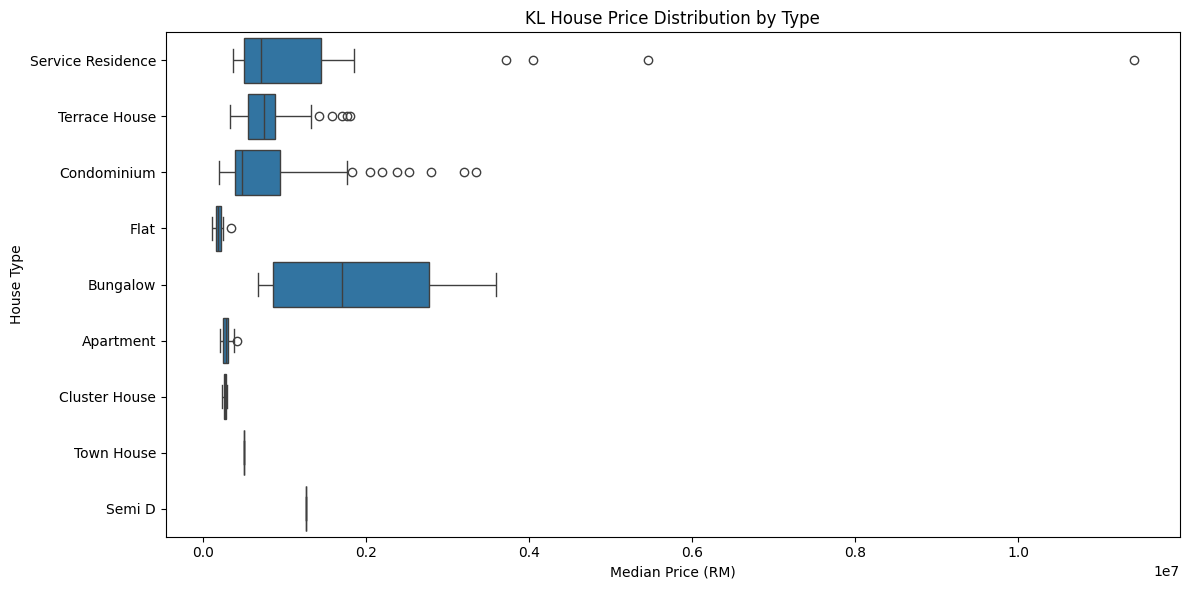

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['State'] == 'Kuala Lumpur'], x='Median_Price', y='Type_Clean')
plt.title('KL House Price Distribution by Type')
plt.xlabel('Median Price (RM)')
plt.ylabel('House Type')
plt.tight_layout()
plt.show()

In [28]:
print("""
6. Kuala Lumpur Deep Dive:
   - Four Seasons Place (Service Residence) is the most expensive township
     at approximately RM 11 million.
   - Bungalows in KL show the widest price range (RM 1M to RM 4M).
   - High-end condominiums contribute significantly to KL's price outliers.
""")


6. Kuala Lumpur Deep Dive:
   - Four Seasons Place (Service Residence) is the most expensive township
     at approximately RM 11 million.
   - Bungalows in KL show the widest price range (RM 1M to RM 4M).
   - High-end condominiums contribute significantly to KL's price outliers.

